In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [68]:
url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Prediction%20dataset.csv"
df = pd.read_csv(url)
df

,State_Name,District_Name,Crop_Year,Season,Crop,Temperature,Humidity,Soil_Moisture,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,36,35,45,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,37,40,46,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,36,41,50,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,37,42,55,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,36,40,54,720.0,165.0
...,...,...,...,...,...,...,...,...,...,...
49994,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Small millets,36,35,45,27.0,7.0
49995,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Soyabean,37,40,46,27.0,32.0
49996,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Sunflower,36,41,50,450.0,213.0
49997,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Urad,37,42,55,1778.0,309.0


In [69]:
df.shape

(49999, 10)

In [70]:
df.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop',
       'Temperature', 'Humidity', 'Soil_Moisture', 'Area', 'Production'],
      dtype='object')

In [71]:
display(df.describe())

,Crop_Year,Temperature,Humidity,Soil_Moisture,Area,Production
count,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,4.978400e+04
mean,2005.879138,34.445489,44.776116,53.110502,7363.389469,4.132019e+05
std,5.106092,3.498524,6.662406,5.258764,27927.935789,1.232609e+07
min,1997.000000,25.000000,35.000000,45.000000,0.200000,0.000000e+00
25%,2002.000000,34.000000,40.000000,50.000000,76.000000,8.700000e+01
50%,2006.000000,36.000000,42.000000,54.000000,436.000000,6.384400e+02
75%,2010.000000,36.000000,50.000000,55.000000,2546.500000,5.615000e+03
max,2014.000000,37.000000,55.000000,62.000000,877029.000000,7.801620e+08


In [72]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State_Name     49999 non-null  object 
 1   District_Name  49999 non-null  object 
 2   Crop_Year      49999 non-null  int64  
 3   Season         49999 non-null  object 
 4   Crop           49999 non-null  object 
 5   Temperature    49999 non-null  int64  
 6   Humidity       49999 non-null  int64  
 7   Soil_Moisture  49999 non-null  int64  
 8   Area           49999 non-null  float64
 9   Production     49784 non-null  float64
dtypes: float64(2), int64(4), object(4)
memory usage: 3.8+ MB


None

In [73]:
display(df.isnull().sum())

,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Temperature,0
Humidity,0
Soil_Moisture,0
Area,0
Production,215


In [74]:
df_clean = df.dropna(subset=['Area', 'Production']).copy()

df_clean = df_clean[df_clean['Area'] > 0]

df_clean['Yield'] = df_clean['Production'] / df_clean['Area']

df_clean['Season'] = df_clean['Season'].str.strip()
df_clean['Crop'] = df_clean['Crop'].str.strip()

print(f"Kích thước dữ liệu sau khi làm sạch: {df_clean.shape}")

display(df_clean[['Crop', 'Area', 'Production', 'Yield']].head())

Kích thước dữ liệu sau khi làm sạch: (49784, 11)


,Crop,Area,Production,Yield
0,Arecanut,1254.0,2000.0,1.594896
1,Other Kharif pulses,2.0,1.0,0.500000
2,Rice,102.0,321.0,3.147059
3,Banana,176.0,641.0,3.642045
4,Cashewnut,720.0,165.0,0.229167


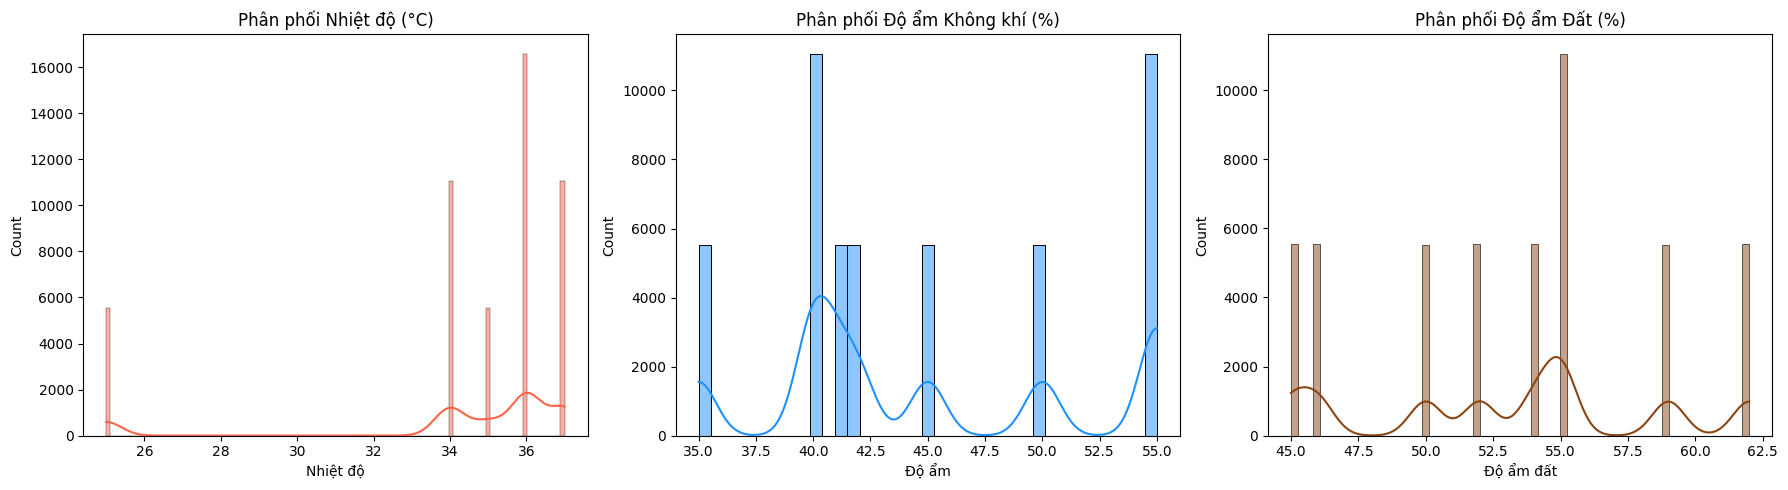

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_clean['Temperature'], kde=True, ax=axes[0], color='tomato')
axes[0].set_title('Phân phối Nhiệt độ (°C)')
axes[0].set_xlabel('Nhiệt độ')

sns.histplot(df_clean['Humidity'], kde=True, ax=axes[1], color='dodgerblue')
axes[1].set_title('Phân phối Độ ẩm Không khí (%)')
axes[1].set_xlabel('Độ ẩm')

sns.histplot(df_clean['Soil_Moisture'], kde=True, ax=axes[2], color='saddlebrown')
axes[2].set_title('Phân phối Độ ẩm Đất (%)')
axes[2].set_xlabel('Độ ẩm đất')

plt.tight_layout()
plt.show()

In [76]:
label_encoders = {}
for col in ['Season', 'Crop']:
        if col in df_clean.columns:
            le = LabelEncoder()
            df_clean[col] = le.fit_transform(df_clean[col])
            label_encoders[col] = le

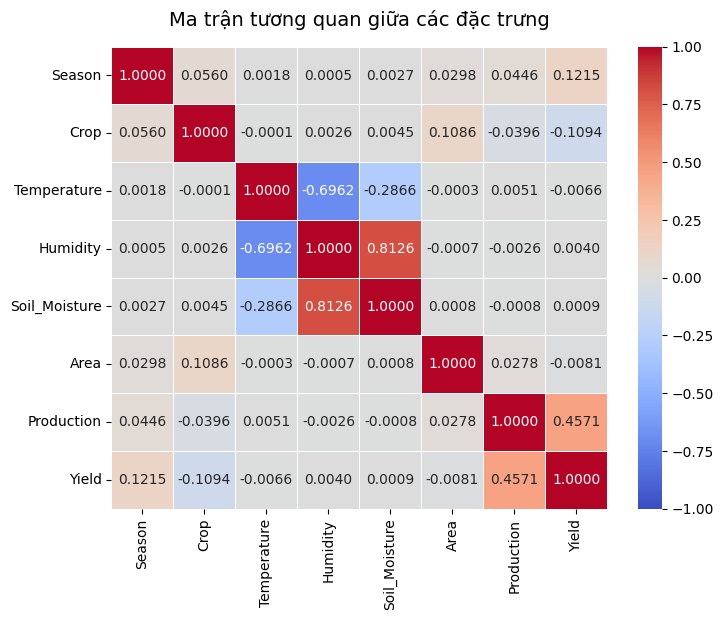

In [77]:
cols_to_drop = ['State_Name', 'District_Name', 'Crop_Year']
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

corr_matrix = df_clean.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt=".4f",
    linewidths=.5
)

plt.title(
    'Ma trận tương quan giữa các đặc trưng',
    fontsize=14,
    pad=15
)

plt.show()

In [78]:
print(df_clean.dtypes)

Season             int64
Crop               int64
Temperature        int64
Humidity           int64
Soil_Moisture      int64
Area             float64
Production       float64
Yield            float64
dtype: object


In [79]:
cols_to_drop = ['Area', 'Production']
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

In [80]:
print(df_clean.dtypes)

Season             int64
Crop               int64
Temperature        int64
Humidity           int64
Soil_Moisture      int64
Yield            float64
dtype: object


In [82]:
display(df_clean['Yield'].head())

,Yield
0,1.594896
1,0.500000
2,3.147059
3,3.642045
4,0.229167
